### Try to load using MLflow API

This doesn't work, scroll below to the next chapter

['val_loss_avg', 'stdev_train_loss', 'val_roc_auc_mood/theme---uplifting', 'avg_train_loss', 'val_loss_std', 'val_macro_pr_auc', 'val_macro_roc_auc', 'val_pr_auc_mood/theme---action', 'val_pr_auc_mood/theme---adventure', 'val_pr_auc_mood/theme---advertising', 'val_pr_auc_mood/theme---background', 'val_pr_auc_mood/theme---ballad', 'val_pr_auc_mood/theme---calm', 'val_pr_auc_mood/theme---children', 'val_roc_auc_mood/theme---melancholic', 'val_roc_auc_mood/theme---melodic', 'val_roc_auc_mood/theme---motivational', 'val_roc_auc_mood/theme---movie', 'val_roc_auc_mood/theme---nature', 'val_roc_auc_mood/theme---party', 'val_roc_auc_mood/theme---positive', 'val_roc_auc_mood/theme---powerful', 'val_roc_auc_mood/theme---relaxing', 'val_roc_auc_mood/theme---retro', 'val_pr_auc_mood/theme---christmas', 'val_pr_auc_mood/theme---commercial', 'val_pr_auc_mood/theme---cool', 'val_pr_auc_mood/theme---corporate', 'val_pr_auc_mood/theme---dark', 'val_pr_auc_mood/theme---deep', 'val_pr_auc_mood/theme---do

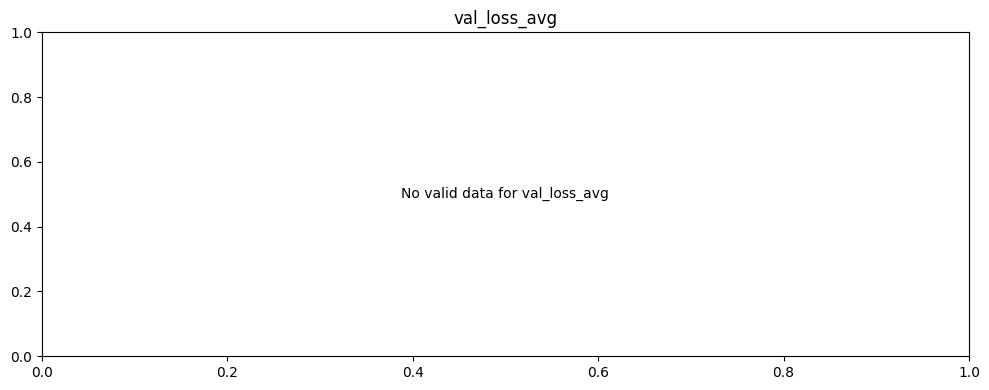

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import mlflow
import traceback
from dotenv import load_dotenv
from mlflow.tracking import MlflowClient

load_dotenv()

tracking_uri = os.getenv("MLFLOW_TRACKING_URI")
mlflow.set_tracking_uri(tracking_uri)  # type: ignore
client: MlflowClient = MlflowClient(tracking_uri=tracking_uri)

# RUN_ID = "906cef2b2f4f465eb47f298a50065e54"
RUN_ID = "15fc890603d149e4918a1c6cfbf9aa48"

METRICS_TO_PLOT: list[str] = [
    # "avg_train_loss",
    "val_loss_avg",
    # "val_macro_pr_auc",
    # "val_macro_roc_auc",
]

run = client.get_run(RUN_ID)
print(list(run.data.metrics.keys()))
# print(run)


def get_and_clean_metric(client: MlflowClient, run_id, metric_key):
    """Fetches metric history from MLflow and removes NaN or None values."""
    try:
        history = client.get_metric_history(run_id, metric_key)
        print("history", history)

        steps = []
        values = []

        for m in history:
            if m.value is not None and not np.isnan(m.value):
                steps.append(m.step)
                values.append(m.value)

        return steps, values

    except Exception as e:
        traceback.print_exc()
        print(f"Could not retrieve '{metric_key}': {e}")
        return [], []


num_metrics = len(METRICS_TO_PLOT)
fig, axes = plt.subplots(nrows=num_metrics, ncols=1, figsize=(10, 4 * num_metrics))

# Check axes is iterable even if there's only one metric
if num_metrics == 1:
    axes = [axes]

for ax, metric_key in zip(axes, METRICS_TO_PLOT):
    steps, values = get_and_clean_metric(client, RUN_ID, metric_key)

    if len(steps) == 0:
        ax.text(
            0.5,
            0.5,
            f"No valid data for {metric_key}",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )
        ax.set_title(metric_key)
        continue

    ax.plot(steps, values, marker="o", linestyle="-", color="b", label=metric_key)
    ax.set_title(f"{metric_key} over Epochs")
    ax.set_xlabel("Epoch / Step")
    ax.set_ylabel("Value")
    ax.grid(True, linestyle="--", alpha=1)
    ax.legend()

plt.tight_layout()
plt.show()

# This works

In [8]:
import pandas as pd

df = pd.read_csv("./mlflow_pgdump/906cef_history.csv")
df.head()

,key,value,timestamp,run_uuid,step,is_nan
0,val_pr_auc_mood/theme---slow,0.045309,1780302780671,906cef2b2f4f465eb47f298a50065e54,0,f
1,val_roc_auc_mood/theme---slow,0.742095,1780302780671,906cef2b2f4f465eb47f298a50065e54,0,f
2,val_roc_auc_mood/theme---movie,0.767623,1780302780671,906cef2b2f4f465eb47f298a50065e54,0,f
3,val_pr_auc_mood/theme---movie,0.108775,1780302780671,906cef2b2f4f465eb47f298a50065e54,0,f
4,val_roc_auc_mood/theme---motivational,0.865343,1780302780671,906cef2b2f4f465eb47f298a50065e54,0,f


In [31]:
def plot_db_metrics(df: pd.DataFrame, metrics_to_plot: list[str]):
    """
    Takes a raw MLflow PostgreSQL metrics dump and a list of metric keys,
    filters out the NaNs, and plots them in stacked subplots.
    """
    num_metrics = len(metrics_to_plot)

    if num_metrics == 0:
        print("No metrics provided to plot.")
        return

    _, axes = plt.subplots(nrows=num_metrics, ncols=1, figsize=(10, 4 * num_metrics))

    if num_metrics == 1:
        axes = [axes]

    for ax, metric_key in zip(axes, metrics_to_plot):
        if "pr" in metric_key:
            df_clean = df[
                (df["key"] == metric_key)
                & (df["is_nan"].isin(["f", "F", False, 0]))
                & (df["value"] > 0.0)
            ].copy()
        elif "roc" in metric_key:
            df_clean = df[
                (df["key"] == metric_key)
                & (df["is_nan"].isin(["f", "F", False, 0]))
                & (df["value"] > 0.5)
            ].copy()
        else:
            df_clean = df[
                (df["key"] == metric_key)
                & (df["is_nan"].isin(["f", "F", False, 0]))
                & (df["value"].notna())
            ].copy()

        df_clean = df_clean.sort_values(by="step")

        # Handle edge case where the metric exists but all values were NaN
        if df_clean.empty:
            ax.text(
                0.5,
                0.5,
                f"No valid data found for '{metric_key}'",
                ha="center",
                va="center",
                transform=ax.transAxes,
            )
            ax.set_title(metric_key)
            continue

        ax.plot(
            df_clean["step"].apply(lambda x: x + 1),
            df_clean["value"],
            marker="o",
            linestyle="-",
            color="b",
            label=metric_key,
        )

        ax.set_title(f"{metric_key} over epochs")
        ax.set_xlabel("epoch")
        ax.set_xticks(np.arange(1, stop=len(df_clean["step"]) + 1))
        ax.set_ylabel("value")
        ax.grid(True, linestyle="--", alpha=0.7)
        ax.legend()

    plt.tight_layout()
    plt.show()

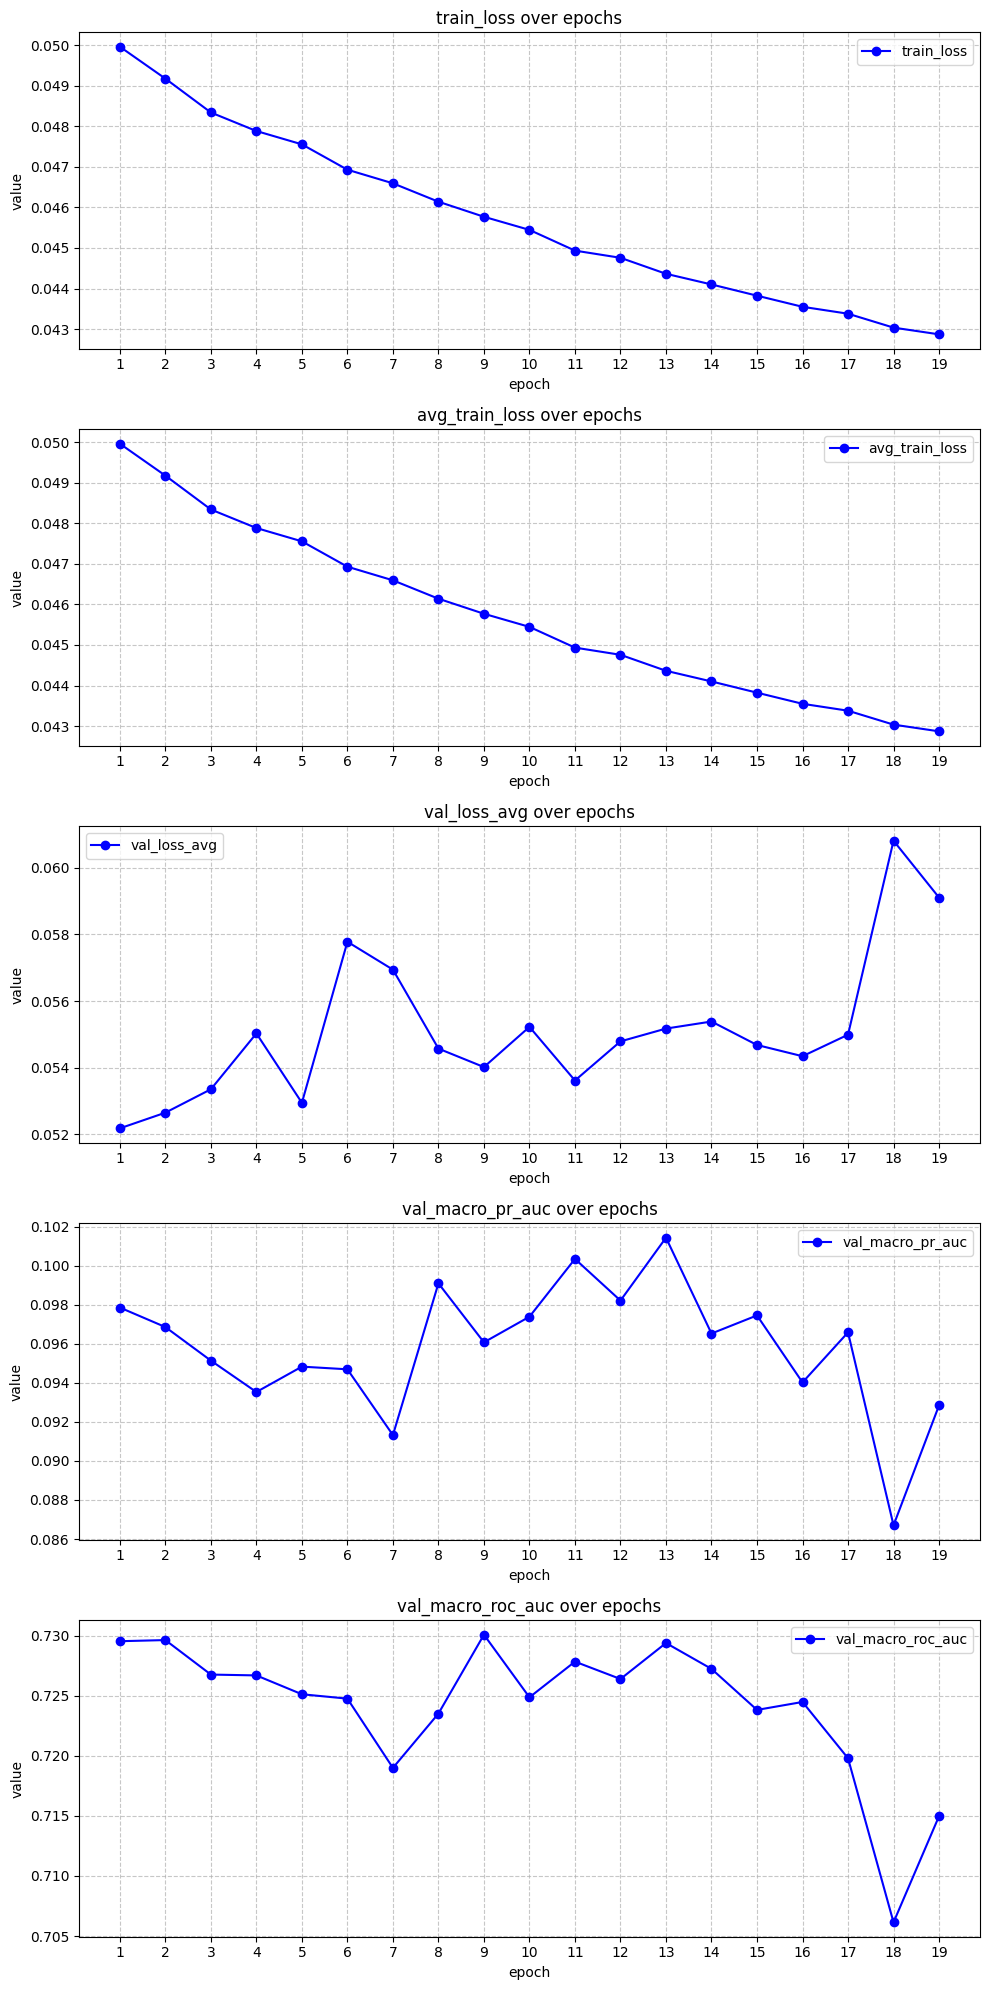

In [32]:
METRICS_TO_PLOT = [
    "train_loss",
    "avg_train_loss",
    "val_loss_avg",
    "val_macro_pr_auc",
    "val_macro_roc_auc"
]

plot_db_metrics(df, METRICS_TO_PLOT)

# Testing results

In [115]:
adf = pd.read_csv("./mlflow_pgdump/f1_test_cnn_history_last.csv")
adf.head()

,key,value,timestamp,run_uuid,step,is_nan
0,test_loss_avg,0.064662,1780409268622,541fa55849ba4c3fa37e9b6eda5f6ff5,0,f
1,test_loss_std,0.050982,1780409268622,541fa55849ba4c3fa37e9b6eda5f6ff5,0,f
2,test_pr_auc_mood/theme---action,0.040893,1780409268622,541fa55849ba4c3fa37e9b6eda5f6ff5,0,f
3,test_roc_auc_mood/theme---action,0.726583,1780409268622,541fa55849ba4c3fa37e9b6eda5f6ff5,0,f
4,test_pr_auc_mood/theme---adventure,0.112183,1780409268622,541fa55849ba4c3fa37e9b6eda5f6ff5,0,f


In [116]:
print(adf[(adf["step"] == 0) & (adf["key"] == "test_macro_pr_auc")])
print(adf[(adf["step"] == 0) & (adf["key"] == "test_macro_roc_auc")])
# print(adf[(adf["step"] == 24) & (adf["key"] == "test_macro_pr_auc")])
# print(adf[(adf["step"] == 24) & (adf["key"] == "test_macro_roc_auc")])

# print(adf[adf["step"] == 24])

exclusion = [
    "test_macro_pr_auc",
    "test_macro_roc_auc",
    "test_loss_avg",
    "test_loss_std",
]

prauc_keys = []
prauc_vals = []
rocauc_keys = []
rocauc_vals = []

for item in adf.iterrows():
    # print(item[1]["key"])
    if item[1]["key"] not in exclusion:
        clean_key = "_".join(item[1]["key"].split("_")[1:]).replace("mood/theme---", "")
        if "pr" in clean_key:
            prauc_keys.append(clean_key)
            prauc_vals.append(item[1]["value"])
        elif "roc" in clean_key:
            rocauc_keys.append(clean_key)
            rocauc_vals.append(item[1]["value"])

        # print(f"{clean_key} {item[1]["value"]}")

print(len(prauc_keys))
print(len(prauc_vals))
print(len(rocauc_keys))
print(len(rocauc_vals))

                   key     value      timestamp  \
114  test_macro_pr_auc  0.115485  1780409268622   

                             run_uuid  step is_nan  
114  541fa55849ba4c3fa37e9b6eda5f6ff5     0      f  
                    key     value      timestamp  \
115  test_macro_roc_auc  0.731221  1780409268622   

                             run_uuid  step is_nan  
115  541fa55849ba4c3fa37e9b6eda5f6ff5     0      f  
56
56
56
56


In [117]:
# for i, item in enumerate(prauc_keys):
    # print(f"{str(item).replace("pr_auc_", "")} {prauc_vals[i]}")
    # print(f"{str(item).replace("pr_auc_", "")}")

In [118]:
for item in prauc_vals:
    print(item)

0.0408933647230387
0.1121825396653787
0.1586817906761555
0.0209479961369381
0.0600199987995573
0.0333473517759366
0.179268649037437
0.1626353960076092
0.129426023289075
0.0172794877080004
0.2039934344841636
0.2539878259357236
0.6764846440181245
0.0692864144909643
0.0323277931975649
0.036788212164646
0.0712749081789876
0.1620594097861733
0.1481592006172958
0.3635493511639905
0.054463260159175
0.3192966855420367
0.0830134839244395
0.0382493175042786
0.040970995083185
0.0352483390081808
0.2509134113739213
0.2111651860741959
0.0349913225059272
0.0136763638210261
0.0720165497501148
0.1426484232681547
0.2012480028784473
0.0397368975838033
0.1011957896033029
0.148341772124092
0.0245642065572664
0.0182454111100767
0.0557940500418155
0.0687128281369893
0.1280737175782319
0.1221777752164789
0.0326033972574418
0.136362590782151
0.0997323756116785
0.0116201443201373
0.0411011388697525
0.0617255501821217
0.0429625516703928
0.0299594740167597
0.0345577652953602
0.5264752493120171
0.1615124323027992


In [119]:
for item in rocauc_vals:
    print(item)

0.7265825491873396
0.6405820468839338
0.7125039964770677
0.5880484296331815
0.7371951644572504
0.6907930541139506
0.7734004889714232
0.7443871495805198
0.739435499080579
0.6166907367478947
0.8093683155425585
0.7791376626428171
0.9271784594867334
0.6893955729804786
0.6497367246764837
0.6677857503346281
0.5929466189266661
0.6404953145917002
0.7559618967713164
0.8081465686719294
0.8878648233486943
0.7688932742967003
0.8530428222209044
0.7449180660888406
0.710429626396013
0.7695011879184712
0.7483280565785654
0.924869234427009
0.7460407365451678
0.5600330956664668
0.5643873940590801
0.7270361335495211
0.8290042354568243
0.6400828192744766
0.6739376534477993
0.6787565584856411
0.564219897410312
0.6450836002320126
0.8620646116335772
0.6947512394027399
0.8159473340711103
0.6960602294912609
0.7396523597095298
0.7800875236833721
0.6946995735541991
0.6637976767584377
0.6782046343567403
0.735525117261763
0.862323359976366
0.7345555422742849
0.798249419503045
0.8586949901752429
0.9313051777618706
